# M1/M2/M3 — XGBoost · LightGBM · Random Forest
**Proyecto Final — Diplomado AI UNI** 

**Autor:** Alvaro Untiveros

| Kernel: `dengue-xgb`

Carga el AMT ya preprocesado y entrena 3 modelos de ensamble con:
- Optimización Optuna
- Stacking como modelo combinado
- Diagnóstico por rango de casos y por cluster LISA
- SHAP para interpretabilidad

## 0. Imports

In [ ]:
import warnings, os, json, pickle
warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import optuna, shap
optuna.logging.set_verbosity(optuna.logging.WARNING)

BASE_DIR   = Path('../')
DATA_INTER = BASE_DIR / 'data' / 'interim'
DATA_PROC  = BASE_DIR / 'data' / 'processed'
DATA_PROC.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi':120, 'figure.figsize':(13,4)})
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__}')
print('Setup OK ✓')

XGBoost 3.2.0 | LightGBM 4.6.0
Setup OK ✓


## 1. Cargar AMT

In [2]:
# Cargar AMT
df = pd.read_parquet(DATA_INTER / 'AMT_final.parquet')
print(f'AMT shape: {df.shape}')

# Cargar metadata de features
with open(DATA_INTER / 'AMT_metadata.json') as f:
    meta = json.load(f)

FEAT_COLS    = meta['all_features']
CORTE_TRAIN  = meta['corte_train']
CORTE_VAL    = meta['corte_val']
USE_LOG      = meta['use_log']
HORIZONTES   = meta['horizontes']

print(f'Features   : {len(FEAT_COLS)}')
print(f'Train hasta: {CORTE_TRAIN}')
print(f'Val hasta  : {CORTE_VAL}')
print(f'Horizontes : {HORIZONTES}')

AMT shape: (908980, 84)
Features   : 41
Train hasta: 2022-12-31
Val hasta  : 2023-12-31
Horizontes : [4, 8, 12]


## 2. Split temporal y función de evaluación

In [3]:
def preparar_split(horizonte, log=True):
    target = f'target_h{horizonte}_log' if log else f'target_h{horizonte}'
    data   = df.dropna(subset=[target] + FEAT_COLS[:5]).copy()
    train  = data[data.fecha <= CORTE_TRAIN]
    val    = data[(data.fecha > CORTE_TRAIN) & (data.fecha <= CORTE_VAL)]
    test   = data[data.fecha > CORTE_VAL]
    def xy(s): return s[FEAT_COLS].fillna(0), s[target]
    def w(s):  return s['sample_weight'].values
    return xy(train), xy(val), xy(test), w(train), train, val, test

(X_tr,y_tr),(X_va,y_va),(X_te,y_te),w_tr,train,val,test = preparar_split(4)
for n,s in [('Train',train),('Val',val),('Test',test)]:
    print(f'{n:5}: {len(s):>8,} filas | '
          f'{s.fecha.min().date()} → {s.fecha.max().date()}')

Train:  482,082 filas | 2018-02-12 → 2022-12-26
Val  :  100,568 filas | 2023-01-02 → 2023-12-25
Test :  296,074 filas | 2024-01-01 → 2026-12-14


In [4]:
resultados = []

def metricas(y_real, y_pred, nombre, horizonte, es_log=True):
    yr = np.array(y_real)
    yp = np.array(y_pred)
    if es_log:
        yr = np.expm1(yr)
        yp = np.expm1(np.clip(yp, 0, None))
    yp = np.clip(yp, 0, None)
    rmse = np.sqrt(mean_squared_error(yr, yp))
    mae  = mean_absolute_error(yr, yp)
    r2   = r2_score(yr, yp)
    print(f'[{nombre:25s} H={horizonte}w] '
          f'RMSE={rmse:7.2f} | MAE={mae:6.2f} | R²={r2:.3f}')
    resultados.append({'modelo':nombre,'horizonte':horizonte,
                       'rmse':rmse,'mae':mae,'r2':r2})
    return yp

def diagnostico_rango(y_real, y_pred, nombre):
    df_d   = pd.DataFrame({'real':y_real,'pred':y_pred})
    bins   = [-1,0,5,20,100,999999]
    labels = ['0','1-5','6-20','21-100','>100']
    df_d['rango'] = pd.cut(df_d['real'], bins=bins, labels=labels)
    print(f'\nDiagnóstico por rango — {nombre}:')
    for rango, g in df_d.groupby('rango', observed=True):
        if len(g) < 5: continue
        rmse = np.sqrt(mean_squared_error(g['real'], g['pred']))
        r2   = r2_score(g['real'],g['pred']) if g['real'].std()>0 else float('nan')
        print(f'  {rango:8s}: {len(g):>7,} filas | RMSE={rmse:7.2f} | R²={r2:.3f}')

def diagnostico_cluster(y_real, y_pred, test_df, nombre):
    df_d = pd.DataFrame({
        'real':y_real,'pred':y_pred,
        'cluster_code': test_df['cluster_code'].values
    })
    LABELS = {4:'HH endémico',1:'LL limpio',2:'LH buffer',0:'ns neutro'}
    print(f'\nDiagnóstico por cluster — {nombre}:')
    for code, label in LABELS.items():
        g = df_d[df_d.cluster_code==code]
        if len(g) < 10: continue
        rmse = np.sqrt(mean_squared_error(g['real'],g['pred']))
        r2   = r2_score(g['real'],g['pred']) if g['real'].std()>0 else float('nan')
        print(f'  {label:15s} ({len(g):>6,}): RMSE={rmse:7.2f} | R²={r2:.3f}')

print('Funciones de evaluación ✓')

Funciones de evaluación ✓


## 3. M1 — XGBoost

Probamos dos variantes para elegir la mejor:
- **log1p + squarederror**: target transformado, objetivo estándar
- **count:poisson**: target original, objetivo correcto para conteos

Usamos `sample_weight` para dar más importancia a los brotes.

In [5]:
# Variante A — log1p
xgb_log = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', eval_metric='rmse',
    early_stopping_rounds=20, n_jobs=-1, random_state=RANDOM_STATE
)
xgb_log.fit(X_tr, y_tr, sample_weight=w_tr,
            eval_set=[(X_va,y_va)], verbose=False)
pred_xgb_log = metricas(y_te, xgb_log.predict(X_te), 'XGBoost log1p', 4)
print(f'Mejor iter: {xgb_log.best_iteration}')

[XGBoost log1p             H=4w] RMSE=  14.67 | MAE=  0.98 | R²=0.312
Mejor iter: 82


In [6]:
# Variante B — Poisson (sin log)
def preparar_split_raw(horizonte):
    target = f'target_h{horizonte}'
    data   = df.dropna(subset=[target]+FEAT_COLS[:5]).copy()
    train  = data[data.fecha <= CORTE_TRAIN]
    val    = data[(data.fecha>CORTE_TRAIN)&(data.fecha<=CORTE_VAL)]
    test   = data[data.fecha > CORTE_VAL]
    def xy(s): return s[FEAT_COLS].fillna(0), s[target].clip(0)
    def w(s):  return s['sample_weight'].values
    return xy(train), xy(val), xy(test), w(train)

(Xp_tr,yp_tr),(Xp_va,yp_va),(Xp_te,yp_te),wp_tr = preparar_split_raw(4)

xgb_poi = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='count:poisson', eval_metric='poisson-nloglik',
    early_stopping_rounds=20, n_jobs=-1, random_state=RANDOM_STATE
)
xgb_poi.fit(Xp_tr, yp_tr, sample_weight=wp_tr,
            eval_set=[(Xp_va,yp_va)], verbose=False)
pred_xgb_poi = metricas(yp_te, xgb_poi.predict(Xp_te),
                         'XGBoost Poisson', 4, es_log=False)
print(f'Mejor iter: {xgb_poi.best_iteration}')

# Diagnóstico del mejor
diagnostico_rango(np.expm1(y_te.values), pred_xgb_log, 'XGBoost log1p')
diagnostico_cluster(np.expm1(y_te.values), pred_xgb_log, test, 'XGBoost log1p')

[XGBoost Poisson           H=4w] RMSE=  14.69 | MAE=  1.05 | R²=0.310
Mejor iter: 189

Diagnóstico por rango — XGBoost log1p:
  0       : 275,887 filas | RMSE=   0.69 | R²=nan
  1-5     :  13,073 filas | RMSE=   2.37 | R²=-2.483
  6-20    :   4,161 filas | RMSE=   7.46 | R²=-2.346
  21-100  :   2,149 filas | RMSE=  29.80 | R²=-1.082
  >100    :     804 filas | RMSE= 276.21 | R²=-1.169

Diagnóstico por cluster — XGBoost log1p:
  HH endémico     (18,150): RMSE=  54.53 | R²=0.271
  LL limpio       (82,467): RMSE=   0.01 | R²=-0.161
  LH buffer       ( 5,206): RMSE=   1.23 | R²=0.415
  ns neutro       (190,251): RMSE=   7.15 | R²=0.393


## 4. M2 — LightGBM

Gradient boosting por histogramas. Ventajas con features dispersas
y alto porcentaje de ceros.

In [7]:
lgb_m = lgb.LGBMRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, num_leaves=63,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
)
lgb_m.fit(
    X_tr, y_tr, sample_weight=w_tr,
    eval_set=[(X_va,y_va)],
    callbacks=[
        lgb.early_stopping(20, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
pred_lgb = metricas(y_te, lgb_m.predict(X_te), 'LightGBM', 4)
print(f'Mejor iter: {lgb_m.best_iteration_}')

[LightGBM                  H=4w] RMSE=  14.35 | MAE=  0.96 | R²=0.342
Mejor iter: 123


## 5. M3 — Random Forest

Bagging de árboles independientes. Robusto ante outliers.
Referencia de comparación dentro de los ensambles.

In [8]:
rf_m = RandomForestRegressor(
    n_estimators=300, max_depth=12,
    min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
)
rf_m.fit(X_tr, y_tr, sample_weight=w_tr)
pred_rf = metricas(y_te, rf_m.predict(X_te), 'Random Forest', 4)
print('RF entrenado ✓')

[Random Forest             H=4w] RMSE=  14.58 | MAE=  0.98 | R²=0.320
RF entrenado ✓


## 6. Optimización Optuna — LightGBM

Búsqueda bayesiana con TPE sobre el espacio de hiperparámetros.
50 trials sobre el set de validación.

In [9]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('lr', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child', 5, 100),
        'reg_alpha'        : trial.suggest_float('alpha', 1e-4, 10, log=True),
        'reg_lambda'       : trial.suggest_float('lambda', 1e-4, 10, log=True),
        'n_jobs': -1, 'random_state': RANDOM_STATE, 'verbose': -1
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(
        X_tr, y_tr, sample_weight=w_tr,
        eval_set=[(X_va,y_va)],
        callbacks=[lgb.early_stopping(15,verbose=False),
                   lgb.log_evaluation(-1)]
    )
    pred = np.expm1(np.clip(m.predict(X_te), 0, None))
    real = np.expm1(y_te.values)
    return np.sqrt(mean_squared_error(real, pred))

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nMejor RMSE Optuna: {study.best_value:.2f}')
print('Mejores params:')
for k,v in study.best_params.items(): print(f'  {k}: {v}')

Best trial: 21. Best value: 14.0516: 100%|██████████| 50/50 [00:53<00:00,  1.08s/it]


Mejor RMSE Optuna: 14.05
Mejores params:
  n_estimators: 295
  max_depth: 9
  lr: 0.13030945409277364
  leaves: 125
  subsample: 0.8078777375978614
  colsample: 0.8044594329160526
  min_child: 32
  alpha: 0.07516113324994943
  lambda: 0.00042389030240414584


In [10]:
# Mapear nombres correctos
param_map = {
    'lr': 'learning_rate',
    'leaves': 'num_leaves', 
    'subsample': 'subsample',
    'colsample': 'colsample_bytree',
    'min_child': 'min_child_samples',
    'alpha': 'reg_alpha',
    'lambda': 'reg_lambda',
    'n_estimators': 'n_estimators',
    'max_depth': 'max_depth'
}
best_p_fixed = {param_map.get(k,k): v for k,v in study.best_params.items()}
best_p_fixed.update({'n_jobs':-1,'random_state':RANDOM_STATE,'verbose':-1})
print('Params corregidos:', best_p_fixed)

lgb_opt2 = lgb.LGBMRegressor(**best_p_fixed)
lgb_opt2.fit(
    X_tr, y_tr, sample_weight=w_tr,
    eval_set=[(X_va,y_va)],
    callbacks=[lgb.early_stopping(15,verbose=False),
               lgb.log_evaluation(period=-1)]
)
pred_lgb_opt2 = metricas(y_te, lgb_opt2.predict(X_te), 'LightGBM Optuna v2', 4)# Diagnóstico cluster correcto — invertir log antes de pasar
diagnostico_cluster(
    np.expm1(y_te.values),
    np.expm1(np.clip(lgb_opt2.predict(X_te), 0, None)),
    test, 'LightGBM Optuna v2'
)


Params corregidos: {'n_estimators': 295, 'max_depth': 9, 'learning_rate': 0.13030945409277364, 'num_leaves': 125, 'subsample': 0.8078777375978614, 'colsample_bytree': 0.8044594329160526, 'min_child_samples': 32, 'reg_alpha': 0.07516113324994943, 'reg_lambda': 0.00042389030240414584, 'n_jobs': -1, 'random_state': 42, 'verbose': -1}
[LightGBM Optuna v2        H=4w] RMSE=  14.05 | MAE=  0.95 | R²=0.369

Diagnóstico por cluster — LightGBM Optuna v2:
  HH endémico     (18,150): RMSE=  51.86 | R²=0.341
  LL limpio       (82,467): RMSE=   0.01 | R²=-0.066
  LH buffer       ( 5,206): RMSE=   1.23 | R²=0.415
  ns neutro       (190,251): RMSE=   7.11 | R²=0.398


## 7. Stacking — XGBoost + LightGBM + RF

Meta-modelo de regresión lineal (pesos positivos) entrenado sobre
las predicciones del set de validación para evitar data leak.

In [12]:
# Meta-features sobre val (para entrenar meta-modelo)
X_meta_val = np.column_stack([
    xgb_log.predict(X_va),
    lgb_opt2.predict(X_va),
    rf_m.predict(X_va)
])
# Meta-features sobre test (para evaluar)
X_meta_te = np.column_stack([
    xgb_log.predict(X_te),
    lgb_opt2.predict(X_te),
    rf_m.predict(X_te)
])

meta = LinearRegression(positive=True)
meta.fit(X_meta_val, y_va)
print(f'Pesos: XGB={meta.coef_[0]:.3f} | LGB={meta.coef_[1]:.3f} | RF={meta.coef_[2]:.3f}')

pred_stack = metricas(y_te, meta.predict(X_meta_te), 'Stacking XGB+LGB+RF', 4)

diagnostico_rango(
    np.expm1(y_te.values),
    np.expm1(np.clip(meta.predict(X_meta_te),0,None)),
    'Stacking'
)

Pesos: XGB=0.322 | LGB=0.467 | RF=0.364
[Stacking XGB+LGB+RF       H=4w] RMSE=  11.94 | MAE=  0.90 | R²=0.544

Diagnóstico por rango — Stacking:
  0       : 275,887 filas | RMSE=   1.21 | R²=nan
  1-5     :  13,073 filas | RMSE=   3.78 | R²=-7.828
  6-20    :   4,161 filas | RMSE=  11.61 | R²=-7.092
  21-100  :   2,149 filas | RMSE=  32.46 | R²=-1.471
  >100    :     804 filas | RMSE= 219.75 | R²=-0.373


## 8. Multihorizonte — LightGBM Optuna

In [14]:
for h in [8, 12]:
    (Xh_tr,yh_tr),(Xh_va,yh_va),(Xh_te,yh_te),wh_tr,*_ = preparar_split(h)
    m = lgb.LGBMRegressor(**best_p_fixed)
    m.fit(
        Xh_tr, yh_tr, sample_weight=wh_tr,
        eval_set=[(Xh_va,yh_va)],
        callbacks=[lgb.early_stopping(15,verbose=False),
                   lgb.log_evaluation(-1)]
    )
    metricas(yh_te, m.predict(Xh_te), 'LightGBM Optuna', h)

[LightGBM Optuna           H=8w] RMSE=  16.11 | MAE=  1.11 | R²=0.166
[LightGBM Optuna           H=12w] RMSE=  15.87 | MAE=  1.07 | R²=0.081


## 9. SHAP — Interpretabilidad

Valores SHAP para el mejor modelo (LightGBM Optuna).
Muestra la contribución de cada feature a cada predicción.

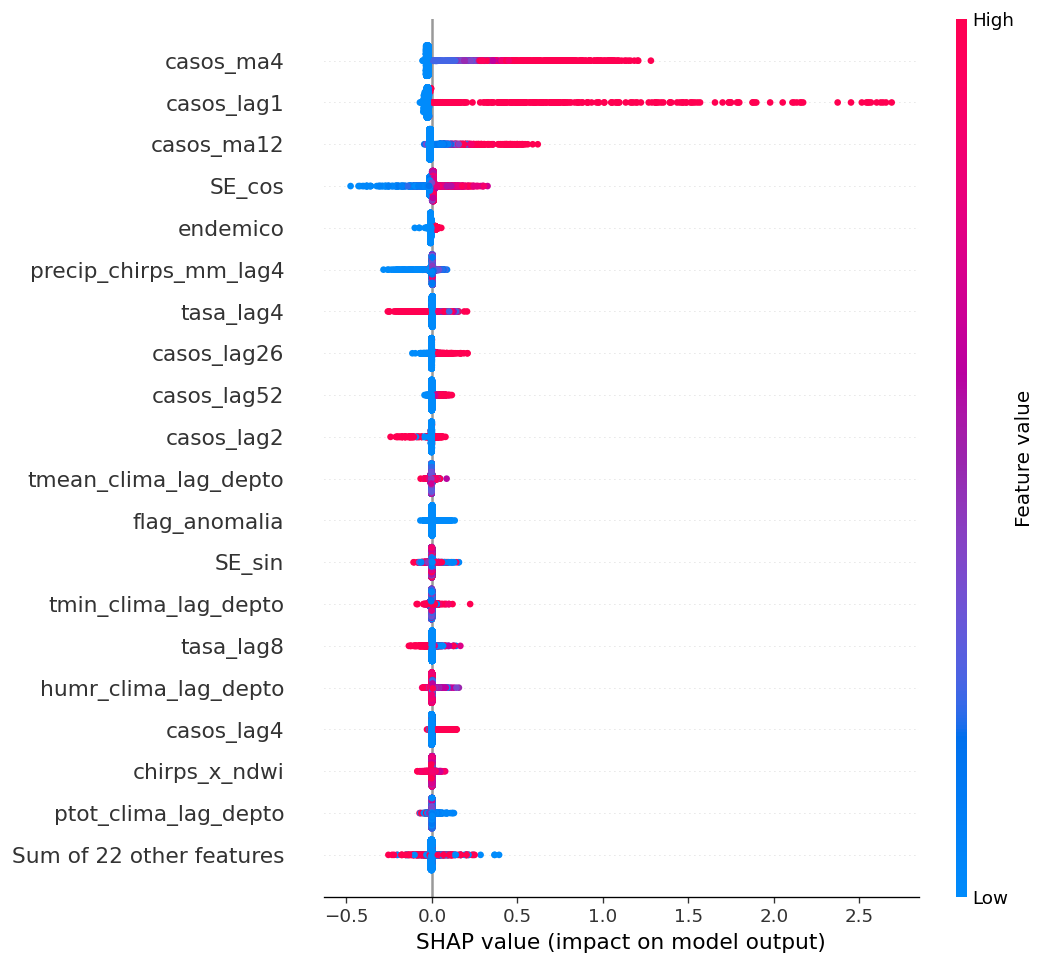

In [16]:
sample_size = min(5000, len(X_te))
X_shap      = X_te.sample(sample_size, random_state=RANDOM_STATE).fillna(0)

explainer   = shap.Explainer(lgb_opt2)
shap_values = explainer(X_shap)

shap.plots.beeswarm(shap_values, max_display=20)

## 10. Tabla comparativa y guardado

In [21]:
df_res = pd.DataFrame(resultados).sort_values('rmse')
print('Resultados:')
display(df_res.style
        .highlight_min(subset=['rmse','mae'], color='#c6efce')
        .highlight_max(subset=['r2'],         color='#c6efce')
        .format({'rmse':'{:.2f}','mae':'{:.2f}','r2':'{:.3f}'}))

# Guardar métricas
df_res.to_csv(DATA_PROC / 'metricas_xgb_lgb_rf.csv', index=False)

# Guardar modelos
xgb_log.save_model(str(DATA_PROC / 'xgb_log.json'))
xgb_poi.save_model(str(DATA_PROC / 'xgb_poisson.json'))
lgb_opt2.booster_.save_model(str(DATA_PROC / 'lgb_optuna.txt'))
with open(DATA_PROC / 'rf_model.pkl','wb') as f: pickle.dump(rf_m, f)
np.save(str(DATA_PROC / 'stack_coef.npy'), meta.coef_)

print('\nTodo guardado ✓')

Resultados:


,modelo,horizonte,rmse,mae,r2
5,Stacking XGB+LGB+RF,4,11.94,0.90,0.544
4,LightGBM Optuna v2,4,14.05,0.95,0.369
2,LightGBM,4,14.35,0.96,0.342
3,Random Forest,4,14.58,0.98,0.320
0,XGBoost log1p,4,14.67,0.98,0.312
1,XGBoost Poisson,4,14.69,1.05,0.310
7,LightGBM Optuna,12,15.87,1.07,0.081
6,LightGBM Optuna,8,16.11,1.11,0.166



Todo guardado ✓
